In [49]:
from const import filtered_turbine_file
from helper import dict_reader
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

reader = dict_reader(filtered_turbine_file)
rows = list(reader)

In [75]:

power_gearbox: dict[int, Counter] = {}
power_generator: dict[int, Counter] = {}
power_gearbox_generator: dict[int, Counter] = {}


gearbox_bucket_size = 1000
generator_bucket_size = 2000
gearbox_generator_bucket_size = 1000

all_gearboxes = set()
all_generators = set()
all_gearbox_generators = set()


def gearbox_lookup(gearbox):
    if not gearbox or gearbox == "#ND":
        return ""
    if gearbox == "No":
        return "dd"
    else:
        return "gb"


def generator_lookup(generator):
    generators_converter = {
        "dfig": ["ASYNC", "ASYNC DF", "DF", "IND", "DFIG"],
        "eesg": ["SYNC", "SYNC Wounded"],
        "pmsg": ["SYNC PM"],
        "": ["#ND"]
    }

    for key, value in generators_converter.items():
        if generator in value:
            return key


for row in rows:
    p = int(row["Rated power"])
    gearbox = gearbox_lookup(row["Gear box"])
    generator = generator_lookup(row["Generators"])
    
    power_gearbox.setdefault((p // gearbox_bucket_size) * gearbox_bucket_size, Counter()).update([gearbox])
    power_generator.setdefault(p // generator_bucket_size * generator_bucket_size, Counter()).update([generator])

    all_gearboxes.add(gearbox)
    all_generators.add(generator)

    
    if gearbox and generator:
        gearbox_generator = f"{gearbox}_{generator}"
        power_gearbox_generator.setdefault(p // gearbox_generator_bucket_size * gearbox_generator_bucket_size,
                                           Counter()).update([gearbox_generator])
        all_gearbox_generators.add(gearbox_generator)

    

power_gearbox_rel = {}
for p, counter in sorted(power_gearbox.items()):
    # print(p, counter)
    values = counter.values()
    total = counter.total()
    rel = {k: v / total for k, v in counter.items()}
    # print(rel)
    power_gearbox_rel[p] = rel

power_generator_rel = {}
for p, counter in sorted(power_generator.items()):
    # print(p, counter)
    values = counter.values()
    total = counter.total()
    rel = {k: v / total for k, v in counter.items()}
    # print(rel)
    power_generator_rel[p] = rel

power_gearbox_generator_rel = {}
power_gearbox_gearbox_spec_generators = {"gb": {}, "dd":{}}

for p, counter in sorted(power_gearbox_generator.items()):
    # print(p, counter)
    values = counter.values()
    total = counter.total()
    rel = {k: v / total for k, v in counter.items()}
    # print(rel)
    power_gearbox_generator_rel[p] = rel
    
    for gearbox_type in ["dd", "gb"]: 
        values = [v for k,v in counter.items() if k.split("_")[0] == gearbox_type]
        total = sum(values)
        rel = {k: v / total for k, v in counter.items() if k.split("_")[0] == gearbox_type}
        # print(rel)
        power_gearbox_gearbox_spec_generators[gearbox_type][p] = rel

In [78]:
power_gearbox_generator

{3000: Counter({'gb_dfig': 13, 'dd_eesg': 8, 'gb_pmsg': 3, 'dd_pmsg': 1}),
 2000: Counter({'gb_dfig': 22, 'dd_eesg': 10}),
 4000: Counter({'dd_eesg': 9, 'gb_dfig': 6, 'dd_pmsg': 3}),
 6000: Counter({'dd_eesg': 3, 'gb_dfig': 2, 'dd_pmsg': 1}),
 5000: Counter({'gb_dfig': 5, 'dd_eesg': 3}),
 0: Counter({'gb_dfig': 14, 'dd_eesg': 11, 'gb_eesg': 2}),
 1000: Counter({'gb_dfig': 14, 'dd_eesg': 4, 'gb_eesg': 1})}

In [77]:
power_gearbox_generator_rel

{0: {'dd_eesg': 0.4074074074074074,
  'gb_eesg': 0.07407407407407407,
  'gb_dfig': 0.5185185185185185},
 1000: {'dd_eesg': 0.21052631578947367,
  'gb_dfig': 0.7368421052631579,
  'gb_eesg': 0.05263157894736842},
 2000: {'dd_eesg': 0.3125, 'gb_dfig': 0.6875},
 3000: {'dd_eesg': 0.32, 'dd_pmsg': 0.04, 'gb_dfig': 0.52, 'gb_pmsg': 0.12},
 4000: {'dd_eesg': 0.5,
  'gb_dfig': 0.3333333333333333,
  'dd_pmsg': 0.16666666666666666},
 5000: {'dd_eesg': 0.375, 'gb_dfig': 0.625},
 6000: {'dd_eesg': 0.5,
  'gb_dfig': 0.3333333333333333,
  'dd_pmsg': 0.16666666666666666}}

In [76]:
power_gearbox_gearbox_spec_generators

{'gb': {0: {'gb_eesg': 0.125, 'gb_dfig': 0.875},
  1000: {'gb_dfig': 0.9333333333333333, 'gb_eesg': 0.06666666666666667},
  2000: {'gb_dfig': 1.0},
  3000: {'gb_dfig': 0.8125, 'gb_pmsg': 0.1875},
  4000: {'gb_dfig': 1.0},
  5000: {'gb_dfig': 1.0},
  6000: {'gb_dfig': 1.0}},
 'dd': {0: {'dd_eesg': 1.0},
  1000: {'dd_eesg': 1.0},
  2000: {'dd_eesg': 1.0},
  3000: {'dd_eesg': 0.8888888888888888, 'dd_pmsg': 0.1111111111111111},
  4000: {'dd_eesg': 0.75, 'dd_pmsg': 0.25},
  5000: {'dd_eesg': 1.0},
  6000: {'dd_eesg': 0.75, 'dd_pmsg': 0.25}}}

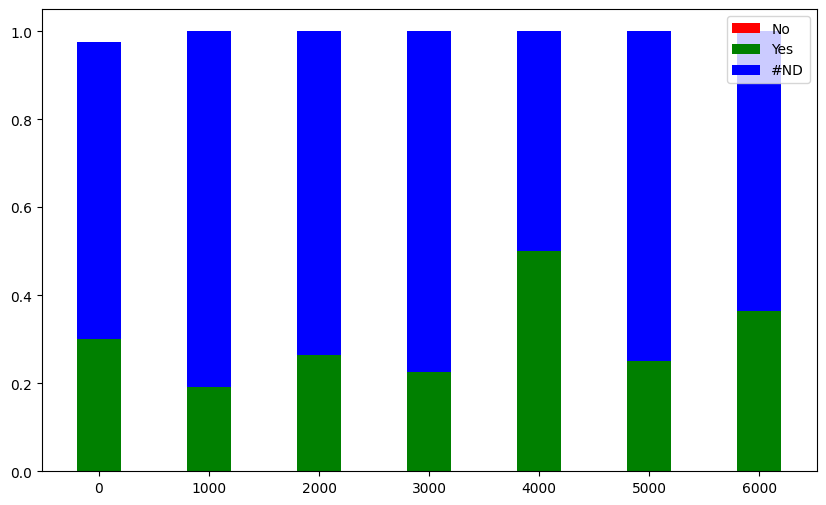

In [62]:
x = np.array(list(power_gearbox_rel.keys()))
bar_values = np.array
no_values = np.array([item.get('nd', 0) for item in power_gearbox_rel.values()])
yes_values = np.array([item.get('dd', 0) for item in power_gearbox_rel.values()])
nd_values = np.array([item.get('gb', 0) for item in power_gearbox_rel.values()])  # Asumiendo 0 si #ND no está presente

# Crear gráfico de barras apiladas
plt.figure(figsize=(10, 6))
plt.bar(x, no_values, width=400, label='No', color='red')
plt.bar(x, yes_values, width=400, label='Yes', color='green', bottom=no_values)
plt.bar(x, nd_values, width=400, label='#ND', color='blue', bottom=no_values + yes_values)

plt.legend()

# Mostrar el gráfico
plt.show()

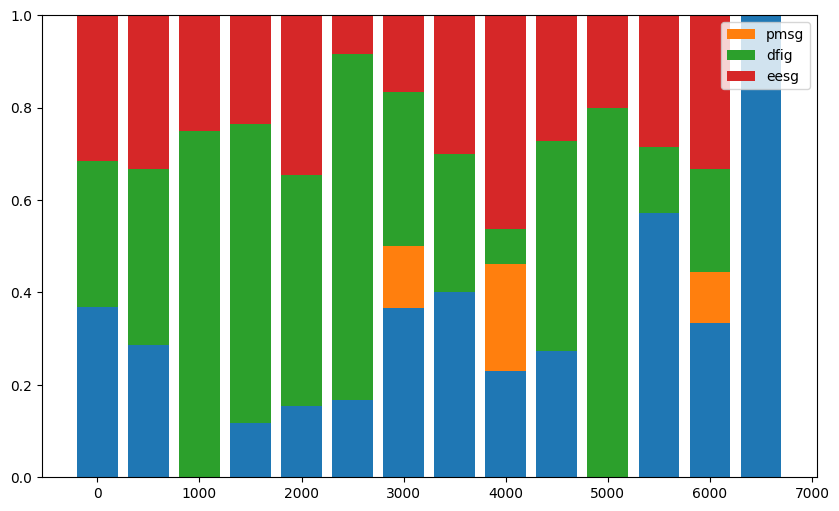

In [40]:
x = np.array(list(power_generator_rel.keys()))

bar_values = []
for gen in all_generators:
    bar_values.append(np.array([item.get(gen, 0) for item in power_generator_rel.values()]))

# no_values = np.array([item.get('No',0) for item in power_gearbox_rel.values()])
# yes_values = np.array([item.get('Yes',0) for item in power_gearbox_rel.values()])
# nd_values = np.array([item.get('#ND', 0) for item in power_gearbox_rel.values()])  # Asumiendo 0 si #ND no está presente

# Crear gráfico de barras apiladas
plt.figure(figsize=(10, 6))
for idx, gen in enumerate(all_generators):
    plt.bar(x, bar_values[idx], width=400, label=gen, bottom=np.sum(bar_values[:idx], axis=0))
# plt.bar(x, no_values, width=400, label='No', color='red')
# plt.bar(x, yes_values, width=400, label='Yes', color='green', bottom=no_values)
# plt.bar(x, nd_values, width=400, label='#ND', color='blue', bottom=no_values+yes_values)

plt.legend()

# Mostrar el gráfico
plt.show()

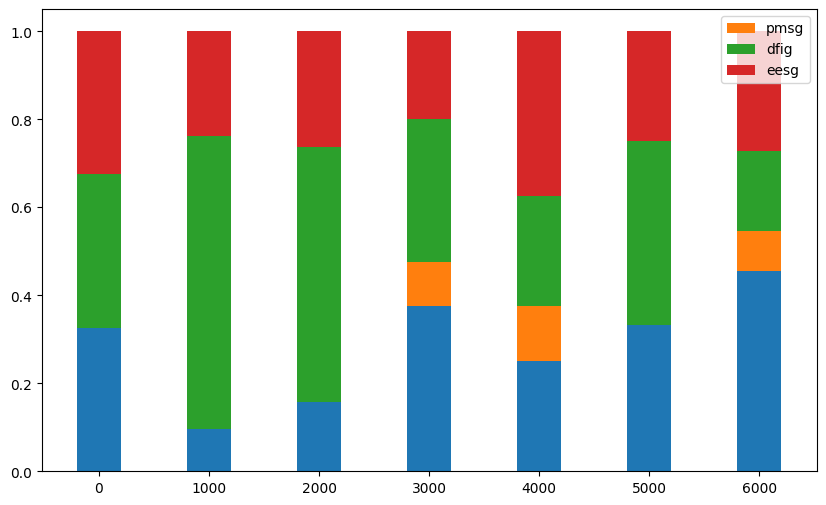

In [42]:
x = np.array(list(power_generator_rel.keys()))

bar_values = []
for gen in all_generators:
    bar_values.append(np.array([item.get(gen, 0) for item in power_generator_rel.values()]))

# no_values = np.array([item.get('No',0) for item in power_gearbox_rel.values()])
# yes_values = np.array([item.get('Yes',0) for item in power_gearbox_rel.values()])
# nd_values = np.array([item.get('#ND', 0) for item in power_gearbox_rel.values()])  # Asumiendo 0 si #ND no está presente

# Crear gráfico de barras apiladas
plt.figure(figsize=(10, 6))
for idx, gen in enumerate(all_generators):
    plt.bar(x, bar_values[idx], width=400, label=gen, bottom=np.sum(bar_values[:idx], axis=0))
# plt.bar(x, no_values, width=400, label='No', color='red')
# plt.bar(x, yes_values, width=400, label='Yes', color='green', bottom=no_values)
# plt.bar(x, nd_values, width=400, label='#ND', color='blue', bottom=no_values+yes_values)

plt.legend()

# Mostrar el gráfico
plt.show()

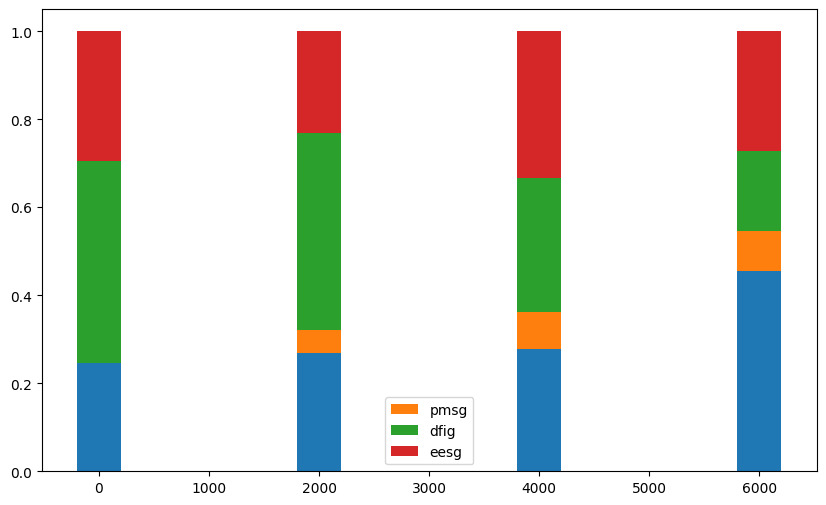

In [44]:
x = np.array(list(power_generator_rel.keys()))

bar_values = []
for gen in all_generators:
    bar_values.append(np.array([item.get(gen, 0) for item in power_generator_rel.values()]))

# Crear gráfico de barras apiladas
plt.figure(figsize=(10, 6))
for idx, gen in enumerate(all_generators):
    plt.bar(x, bar_values[idx], width=400, label=gen, bottom=np.sum(bar_values[:idx], axis=0))

plt.legend()

# Mostrar el gráfico
plt.show()

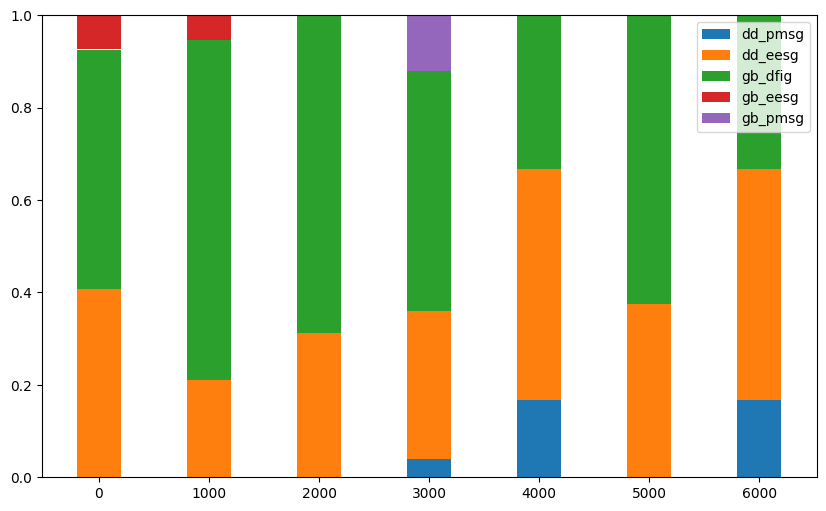

In [67]:

x = np.array(list(power_gearbox_generator_rel.keys()))

bar_values = []
for gen in all_gearbox_generators:
    bar_values.append(np.array([item.get(gen, 0) for item in power_gearbox_generator_rel.values()]))

# Crear gráfico de barras apiladas
plt.figure(figsize=(10, 6))
for idx, gen in enumerate(all_gearbox_generators):
    plt.bar(x, bar_values[idx], width=400, label=gen, bottom=np.sum(bar_values[:idx], axis=0))

plt.legend()

# Mostrar el gráfico
plt.show()

In [66]:
power_gearbox_generator

{3000: Counter({'gb_dfig': 13, 'dd_eesg': 8, 'gb_pmsg': 3, 'dd_pmsg': 1}),
 2000: Counter({'gb_dfig': 22, 'dd_eesg': 10}),
 4000: Counter({'dd_eesg': 9, 'gb_dfig': 6, 'dd_pmsg': 3}),
 6000: Counter({'dd_eesg': 3, 'gb_dfig': 2, 'dd_pmsg': 1}),
 5000: Counter({'gb_dfig': 5, 'dd_eesg': 3}),
 0: Counter({'gb_dfig': 14, 'dd_eesg': 11, 'gb_eesg': 2}),
 1000: Counter({'gb_dfig': 14, 'dd_eesg': 4, 'gb_eesg': 1})}

In [68]:
power_gearbox_generator_rel

{0: {'dd_eesg': 0.4074074074074074,
  'gb_eesg': 0.07407407407407407,
  'gb_dfig': 0.5185185185185185},
 1000: {'dd_eesg': 0.21052631578947367,
  'gb_dfig': 0.7368421052631579,
  'gb_eesg': 0.05263157894736842},
 2000: {'dd_eesg': 0.3125, 'gb_dfig': 0.6875},
 3000: {'dd_eesg': 0.32, 'dd_pmsg': 0.04, 'gb_dfig': 0.52, 'gb_pmsg': 0.12},
 4000: {'dd_eesg': 0.5,
  'gb_dfig': 0.3333333333333333,
  'dd_pmsg': 0.16666666666666666},
 5000: {'dd_eesg': 0.375, 'gb_dfig': 0.625},
 6000: {'dd_eesg': 0.5,
  'gb_dfig': 0.3333333333333333,
  'dd_pmsg': 0.16666666666666666}}